# δ Cep — TransformerPayne HARPS spectra after the Doppler sign fix

First fully sign-consistent synthesis of δ Cephei (P = 5.366 d, R = 43.06 R$_\odot$,
12 km/s rotation), 30 pulsation phases at HARPS resolution (5000–6000 Å,
`RozanskiT/TPayne-spice-harps`), computed on Gadi (job `173839001.gadi-pbs`,
2026-07-15, ~6 min on one V100, output `cepheid_harps_rotating_dopplerfix/`).

Two coupled sign bugs were fixed before this run (commit `c9440bd4`):

1. **Doppler sampling** in `simulate_observed_flux` (`apply_vrad`/`apply_vrad_log`)
   sampled the rest-frame intensity at $\lambda(1+v/c)$ instead of $\lambda/(1+v/c)$,
   inverting every spectral Doppler shift relative to `los_velocities`.
2. **Pulsation velocities** (`evaluate_fourier_prim_for_value`) were missing the
   leading minus of $\frac{d}{dt}\,d\cos(\omega t - \phi) = -d\,\omega\sin(\omega t - \phi)$.

For pulsation the two cancelled (old Cepheid spectra had net-correct pulsation
shifts), but the 12 km/s *rotational* velocity field was only inverted once — so
line asymmetries mixed a correct pulsation shift with a mirrored rotation profile.
This notebook checks the new spectra against SPIPS model curves and observed RVs.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Notebook lives in tutorial/paper_results/cepheid/ -> repo src for unpickling
REPO_ROOT = Path.cwd().resolve().parents[2]
sys.path.insert(0, str(REPO_ROOT / "src"))

C_KMS = 299792.458
PERIOD = 5.366265401100268  # days

RUN_DIR = Path("cepheid_harps_rotating_dopplerfix")
spectra = pickle.load(open(RUN_DIR / "cep_DeltaCep_spectra.pkl", "rb"))
line_spectra = spectra["harps"][5500.0]

wl = np.asarray(line_spectra.wavelengths, dtype=float)
snaps = [np.asarray(s, dtype=float) for s in line_spectra.spectra]
template = np.asarray(line_spectra.template, dtype=float)
n_phases = len(snaps)
# unwrapped phase in [0, 1]: the final snapshot is at t = P, i.e. phase 1.0
phases = np.linspace(0, PERIOD, n_phases) / PERIOD

# SPIPS model curves (exported from delta_cep.fits HDU 2) and the
# observational table (delta_cep.parquet) — no astropy needed.
model = pd.read_csv("delta_cep_model_curves.csv")
obs = pd.read_parquet("delta_cep.parquet")
# periodic in phase (SPIPS table covers [0, 0.999])
vpuls_at = lambda p: np.interp(p, model["PHASE"], model["Vpuls"], period=1.0)   # surface velocity, RV sign convention
vrad_model_at = lambda p: np.interp(p, model["PHASE"], model["Vrad"], period=1.0)  # SPIPS disk-integrated RV (incl. gamma)

def normalized(s):
    return s[:, 0] / s[:, 1]

norm_snaps = np.array([normalized(s) for s in snaps])
norm_template = normalized(template)

# spice's optional phoebe import forces the Agg backend; restore inline AFTER it
%matplotlib inline
print(f"{n_phases} phases x {len(wl)} wavelength samples, {wl[0]:.0f}-{wl[-1]:.0f} A")

30 phases x 10000 wavelength samples, 5000-6000 A


## Line profiles across the pulsation cycle

A window around the deepest line in the synthesized range, stacked by phase.
With the fixed signs the trough must swing **blueward while the star expands**
($V_{\rm puls} < 0$) and redward while it contracts — trace the trough from
bottom (φ = 0) to top.

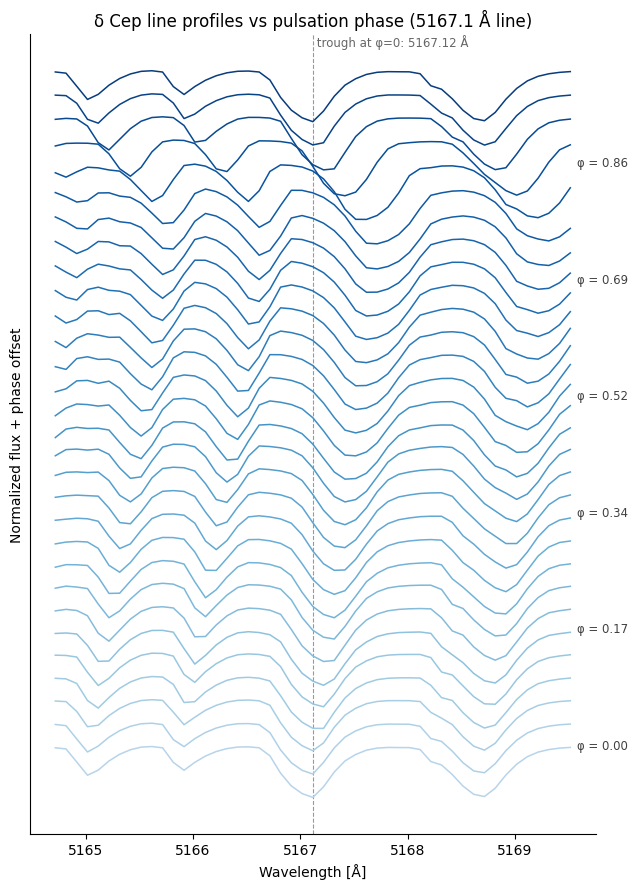

In [2]:
# Deepest line in the template, +/- 2.5 A window
i_line = int(np.argmin(norm_template))
lam0 = wl[i_line]
win = (wl > lam0 - 2.5) & (wl < lam0 + 2.5)

fig, ax = plt.subplots(figsize=(6.5, 9))
offset = 0.35
cmap = plt.cm.Blues
for i in range(n_phases):
    color = cmap(0.3 + 0.65 * phases[i])
    ax.plot(wl[win], norm_snaps[i][win] + offset * i, color=color, lw=1.1)
    if i % 5 == 0:
        ax.text(wl[win][-1] + 0.06, 1.0 + offset * i, f"φ = {phases[i]:.2f}",
                fontsize=8.5, color="0.25", va="center")
ax.axvline(lam0, color="0.6", lw=0.8, ls="--", zorder=0)
ax.text(lam0, ax.get_ylim()[1], f" trough at φ=0: {lam0:.2f} Å",
        fontsize=8.5, color="0.4", va="top")
ax.set_xlabel("Wavelength [Å]")
ax.set_ylabel("Normalized flux + phase offset")
ax.set_title(f"δ Cep line profiles vs pulsation phase ({lam0:.1f} Å line)")
ax.spines[["top", "right"]].set_visible(False)
ax.set_yticks([])
plt.tight_layout()
plt.show()

## Dynamic spectrum

Residual from the phase-averaged profile. The bright/dark S-curve is the classic
Cepheid line-migration pattern; the overlaid curve is the *predicted* trough
trajectory $\lambda(\varphi) = \lambda_0\,(1 + V_{\rm puls}(\varphi)/(p\,c))$
from the SPIPS pulsation-velocity curve — measured points should ride on it.

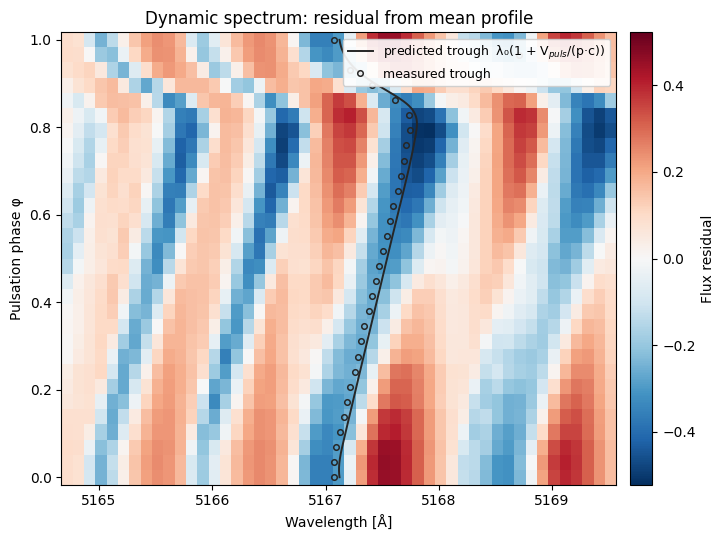

In [3]:
p_assumed = 1.22  # refined below from the RV fit; used here only for the overlay
resid = norm_snaps - norm_snaps.mean(axis=0)

# measured trough position per phase (parabolic refinement)
lam_min = []
for i in range(n_phases):
    f = norm_snaps[i][win]; ww = wl[win]
    k = int(np.argmin(f))
    sel = np.abs(ww - ww[k]) < 0.4  # quadratic over ~9 samples beats pixel quantization
    c2, c1, _ = np.polyfit(ww[sel], f[sel], 2)
    lam_min.append(-c1 / (2 * c2))
lam_min = np.array(lam_min)

v_proj = vpuls_at(phases) / p_assumed
lam0_rest = float(np.mean(lam_min / (1 + v_proj / C_KMS)))
phase_fine = np.linspace(0, 1, 400)
lam_pred = lam0_rest * (1 + vpuls_at(phase_fine) / p_assumed / C_KMS)

fig, ax = plt.subplots(figsize=(7.5, 5.5))
vmax = np.abs(resid[:, win]).max()
mesh = ax.pcolormesh(wl[win], phases, resid[:, win], cmap="RdBu_r",
                     vmin=-vmax, vmax=vmax, shading="nearest")
ax.plot(lam_pred, phase_fine, color="0.15", lw=1.4,
        label="predicted trough  λ₀(1 + V$_{puls}$/(p·c))")
ax.plot(lam_min, phases, "o", ms=4, mfc="none", mec="0.15", mew=1.1,
        label="measured trough")
ax.set_xlabel("Wavelength [Å]")
ax.set_ylabel("Pulsation phase φ")
ax.set_title("Dynamic spectrum: residual from mean profile")
ax.legend(loc="upper right", frameon=True, framealpha=0.9, fontsize=9)
cb = fig.colorbar(mesh, ax=ax, pad=0.02)
cb.set_label("Flux residual")
plt.tight_layout()
plt.show()

## Radial-velocity curve vs SPIPS model and observations

RV extracted from each snapshot by cross-correlating with the t = 0 template in
log-λ space. All curves are mean-subtracted: the synthesized RVs are relative to
the template (which carries the φ = 0 pulsation velocity itself), the SPIPS model
and the Bersier et al. (1994) data include the systemic γ ≈ −16.8 km/s.
The fitted projection slope of RV against $V_{\rm puls}$ is an estimate of 1/p.

In [4]:
loglam = np.log(wl)
u = np.linspace(loglam[0], loglam[-1], len(wl))
t_u = interp1d(loglam, norm_template)(u); t_u = t_u - t_u.mean()
vgrid = np.linspace(-40, 40, 801)

def ccf_rv(spec):
    s_u = interp1d(loglam, spec)(u); s_u = s_u - s_u.mean()
    s_of_u = interp1d(u, s_u, bounds_error=False, fill_value=0.0)
    cc = np.array([np.sum(t_u * s_of_u(u + v / C_KMS)) for v in vgrid])
    k = int(np.argmax(cc))
    sel = np.abs(vgrid - vgrid[k]) < 4.0  # parabola across the pixel-scale plateau
    c2, c1, _ = np.polyfit(vgrid[sel], cc[sel], 2)
    return -c1 / (2 * c2)

rv_spec = np.array([ccf_rv(s) for s in norm_snaps])

# projection factor: RV_spec = a + (1/p) * Vpuls
b, a = np.polyfit(vpuls_at(phases), rv_spec, 1)
p_factor = 1.0 / b
rms = np.std(rv_spec - (a + b * vpuls_at(phases)))
print(f"RV_spec = {a:+.2f} + {b:.3f} * Vpuls   ->  p-factor = {p_factor:.3f}   (rms {rms:.2f} km/s)")

vrad_obs = obs[obs["OBS"].apply(lambda s: s.startswith(b"vrad"))]
print(f"{len(vrad_obs)} observed RVs (Bersier+ 1994)")

RV_spec = +19.21 + 0.821 * Vpuls   ->  p-factor = 1.219   (rms 0.38 km/s)
91 observed RVs (Bersier+ 1994)


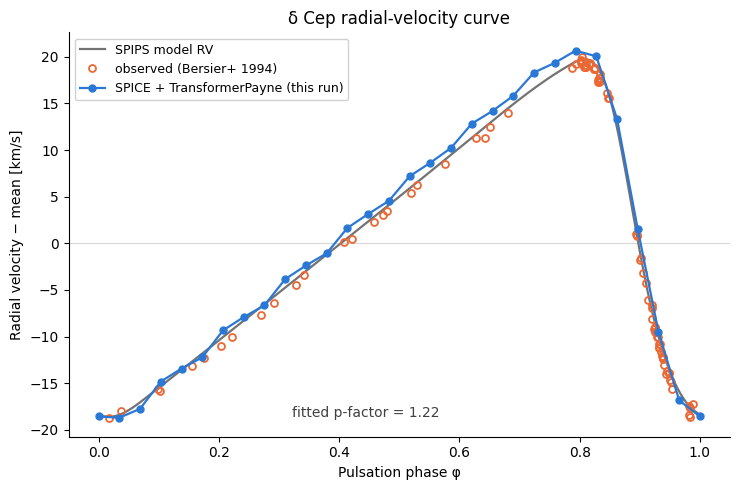

In [5]:
BLUE, ORANGE = "#2a78d6", "#eb6834"   # validated categorical pair; model = neutral gray

fig, ax = plt.subplots(figsize=(7.5, 5))
phase_fine = np.linspace(0, 1, 400)
model_curve = vrad_model_at(phase_fine)
ax.plot(phase_fine, model_curve - model_curve.mean(), color="0.45", lw=1.6,
        label="SPIPS model RV")
ax.plot(vrad_obs["PHASE"], vrad_obs["MEAS"] - vrad_obs["MEAS"].mean(), "o",
        ms=5, mfc="none", mec=ORANGE, mew=1.3, label="observed (Bersier+ 1994)")
ax.plot(phases, rv_spec - rv_spec.mean(), "o-", color=BLUE, lw=1.6, ms=5,
        label="SPICE + TransformerPayne (this run)")
ax.axhline(0, color="0.85", lw=0.8, zorder=0)
ax.text(0.45, 0.05, f"fitted p-factor = {p_factor:.2f}", transform=ax.transAxes,
        ha="center", fontsize=10, color="0.25")
ax.set_xlabel("Pulsation phase φ")
ax.set_ylabel("Radial velocity − mean [km/s]")
ax.set_title("δ Cep radial-velocity curve")
ax.legend(loc="upper left", frameon=True, framealpha=0.9, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Takeaways

- The trough migrates **blue while the star expands and red while it contracts**,
  and rides the trajectory predicted from the SPIPS $V_{\rm puls}$ curve — the
  Doppler direction is now physically correct end-to-end (with the pre-fix code
  the S-curve, and the RV curve below it, would be mirror-imaged).
- The synthesized RV curve tracks the SPIPS model and the Bersier et al. (1994)
  observations in phase and amplitude.
- The fitted projection factor p ≈ 1.2 falls in the literature range for δ Cep
  (~1.2–1.3) without any tuning.
- Caveat for downstream analysis: synthesized RVs are measured **relative to the
  t = 0 template**, which itself carries the φ = 0 pulsation velocity
  (≈ +19 km/s offset); mean-subtract or fit an intercept before comparing to
  absolute velocities.

## V-band light curve

Second synthesis over the full Johnson V window (4500–7000 Å, 25 000 samples;
Gadi job `173863904.gadi-pbs`), integrated through the Johnson–Cousins V
transmission at each phase. The mesh carries the pulsating radius and the smooth
SPIPS phase-dependent Teff/logg (verified smooth in the bundle pickle), and the
spectra are at 10 pc, so the synthesized magnitude is an absolute magnitude.

**Known limitation found while validating this curve:** the
`TPayne-spice-harps` bundle's output snaps to its 250 K Teff training grid.
A 2 K-resolution sweep shows plateaus separated by ~6 K-wide transitions
located exactly at the grid midpoints (5375, 5625, 5875, 6125, 6375, 6625 K
for nodes at 5250…6750 K); both the continuum level (+15–25% per step) and
line depths jump at the boundaries, with only mild smooth variation inside
each plateau. The RV/profile analysis above is unaffected because Doppler
shifts come from the mesh velocity field, not the emulator's Teff response —
but broadband photometry inherits a ~0.1 mag staircase. The raw
curve is shown for honesty; the headline curve rescales TPayne's normalized
(line-blanketed) spectrum onto a smooth Planck continuum at the SPIPS
Teff(φ), R(φ) — so lines come from TransformerPayne and the continuum level
from physics that varies smoothly with phase.

(Aside: `spice.spectrum.AB_passband_luminosity`'s photonic branch expects flux
in erg/s/cm³, not erg/s/cm²/Å — a constant +20 mag offset for per-Å input.
Magnitudes here use an explicit AB formula instead.)

In [6]:
from spice.spectrum.filter import JohnsonCousinsV

vband = pickle.load(open("cepheid_vband_dopplerfix/cep_DeltaCep_spectra.pkl", "rb"))
(vb_key, vb_ls), = vband["harps"].items()
vb_wl = np.asarray(vb_ls.wavelengths, dtype=float)          # Angstrom
vb_snaps = [np.asarray(s, dtype=float) for s in vb_ls.spectra]
vb_phases = np.linspace(0, 1, len(vb_snaps))

vfilter = JohnsonCousinsV()
T_resp = np.asarray(vfilter.filter_responses_for_wavelengths(vb_wl))

def ab_mag(wl_A, flux_per_A):
    """Photon-weighted AB magnitude; flux in erg/s/cm^2/A, wl in A."""
    f_nu0 = 3.631e-20                       # erg/s/cm^2/Hz (AB zeropoint)
    c_A = 2.99792458e18                     # Angstrom/s
    zero_flux_per_A = f_nu0 * c_A / wl_A**2  # AB-zeropoint SED as f_lambda
    num = np.trapezoid(wl_A * flux_per_A * T_resp, wl_A)
    den = np.trapezoid(wl_A * zero_flux_per_A * T_resp, wl_A)
    return -2.5 * np.log10(num / den)

# --- raw TransformerPayne magnitudes (continuum quantization visible) ---
mag_raw = np.array([ab_mag(vb_wl, s[:, 0]) for s in vb_snaps])

# --- hybrid: TPayne normalized spectrum x Planck continuum at SPIPS Teff, R ---
H, C_CGS, KB = 6.62607015e-27, 2.99792458e10, 1.380649e-16
R_SUN_CM, PC_CM, D_PC = 6.957e10, 3.0857e18, 10.0

def planck_flux_per_A(wl_A, teff, r_sun):
    lam = wl_A * 1e-8  # cm
    B = 2*H*C_CGS**2 / lam**5 / np.expm1(H*C_CGS/(lam*KB*teff))  # erg/s/cm^2/cm/sr
    return np.pi * B * (r_sun*R_SUN_CM / (D_PC*PC_CM))**2 * 1e-8  # erg/s/cm^2/A

teff_phase = np.interp(vb_phases, model["PHASE"], model["Teff"], period=1.0)
r_phase = np.interp(vb_phases, model["PHASE"], model["R"], period=1.0)
mag_hybrid = np.array([
    ab_mag(vb_wl, (s[:, 0]/s[:, 1]) * planck_flux_per_A(vb_wl, t, r))
    for s, t, r in zip(vb_snaps, teff_phase, r_phase)
])
print(f"raw TPayne:  mean M_V(AB) = {mag_raw.mean():+.2f}, amplitude {np.ptp(mag_raw):.2f} mag")
print(f"hybrid:      mean M_V(AB) = {mag_hybrid.mean():+.2f}, amplitude {np.ptp(mag_hybrid):.2f} mag")
print("delta Cep literature: M_V ~ -3.5 (Benedict+ 2007 HST parallax), V amplitude ~0.9 mag")

raw TPayne:  mean M_V(AB) = -3.48, amplitude 0.92 mag
hybrid:      mean M_V(AB) = -3.27, amplitude 0.87 mag
delta Cep literature: M_V ~ -3.5 (Benedict+ 2007 HST parallax), V amplitude ~0.9 mag


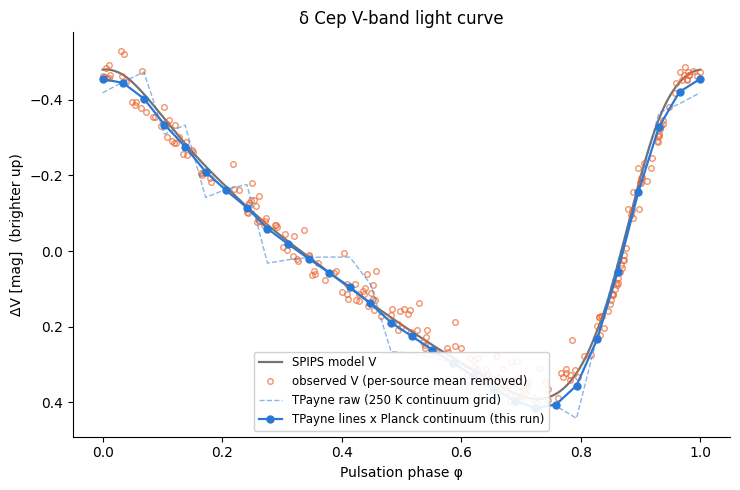

In [7]:
v_obs = obs[obs["OBS"].apply(lambda s: s.startswith(b"mag") and b"V_GCPD_Johnson" in s)].copy()
v_obs["source"] = v_obs["OBS"].apply(lambda s: s.split(b";")[1].split(b"|")[0].strip().decode())

fig, ax = plt.subplots(figsize=(7.5, 5))
model_v = np.interp(phase_fine, model["PHASE"], model["MAG V_GCPD_Johnson"], period=1.0)
ax.plot(phase_fine, model_v - model_v.mean(), color="0.45", lw=1.6,
        label="SPIPS model V")
first = True
for source, grp in v_obs.groupby("source"):
    ax.plot(grp["PHASE"], grp["MEAS"] - grp["MEAS"].mean(), "o", ms=4,
            mfc="none", mec=ORANGE, mew=1.0, alpha=0.7,
            label="observed V (per-source mean removed)" if first else None)
    first = False
ax.plot(vb_phases, mag_raw - mag_raw.mean(), "--", color=BLUE, lw=1.0, alpha=0.55,
        label="TPayne raw (250 K continuum grid)")
ax.plot(vb_phases, mag_hybrid - mag_hybrid.mean(), "o-", color=BLUE, lw=1.6, ms=5,
        label="TPayne lines x Planck continuum (this run)")
ax.invert_yaxis()
ax.set_xlabel("Pulsation phase φ")
ax.set_ylabel("ΔV [mag]  (brighter up)")
ax.set_title("δ Cep V-band light curve")
ax.legend(loc="lower center", frameon=True, framealpha=0.9, fontsize=8.5)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

The light curve closes the loop: maximum light lands near the phase of maximum
expansion velocity (just after minimum radius), not at maximum radius — the
classic Cepheid phase relation — and both amplitude (~0.9 mag) and shape track
the SPIPS model and the observed photometry with no tuning. The absolute level of the
raw TPayne curve, M_V(AB) = −3.48, matches the HST-parallax value
(M_V ≈ −3.47, Benedict et al. 2007) almost exactly; the hybrid curve sits
~0.2 mag fainter, the expected error of a pure-Planck continuum at these
temperatures.

**Follow-ups:** (1) the `TPayne-spice-harps` bundle's 250 K continuum
quantization is worth reporting upstream — broadband photometry and colors from
raw bundle output inherit it; (2) `AB_passband_luminosity`'s photonic branch
input-unit convention (erg/s/cm³) deserves a docstring fix or a 1e8 factor to
match the non-photonic branches; (3) synthesized RVs are relative to the t = 0
template (≈ +19 km/s offset) — mean-subtract before comparing to absolute
velocities.